# Pilot NO2NO3 Measurement in Soil without Rewetting
Written by Kiseok Lee and Karna Gowda, edited by Ikchang Cho
Dates: 20240917 ~ 20240919
Testing Question: NO2NO3 dynamics before rewetting

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('./custom_functions')
import pandas as pd
import numpy as np
import griess_20240926 as gr
import bmgdata as bd
import glob
import denitfit as dn
import pickle
import matplotlib.pyplot as plt
import importlib

# figure size and font size
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

## Make output directory



In [ ]:
newpath = r'./20240926_output'
if not os.path.exists(newpath):
    os.makedirs(newpath)

## 1. Standard curves with griess assay

## 1.1. 2M KCl based standard curves (not from 10/6/21 stock)

### (1) Using bubble removal using well scan (well quadrant bubble correction)

./240907_Griess/standards_metadata.csv
None
./240907_Griess\standard_20240907_Absorbance_KL_NO2_SCAN_540.csv
./240907_Griess\standard_20240907_Absorbance_KL_NO2_SCAN_900.csv
./240907_Griess\standard_20240908_Absorbance_KL_NO2NO3_SCAN_540.csv
./240907_Griess\standard_20240908_Absorbance_KL_NO2NO3_SCAN_900.csv
returns true for elements more than 1 interquartile ranges above the upper quartile
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []
returns true for elements more than 1 interquartile ranges above the upper quartile
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0223           0.0050   -4.4526    0.0001
1        2.2506           0.0186  120.6997    0.0000
2       -0.1266     

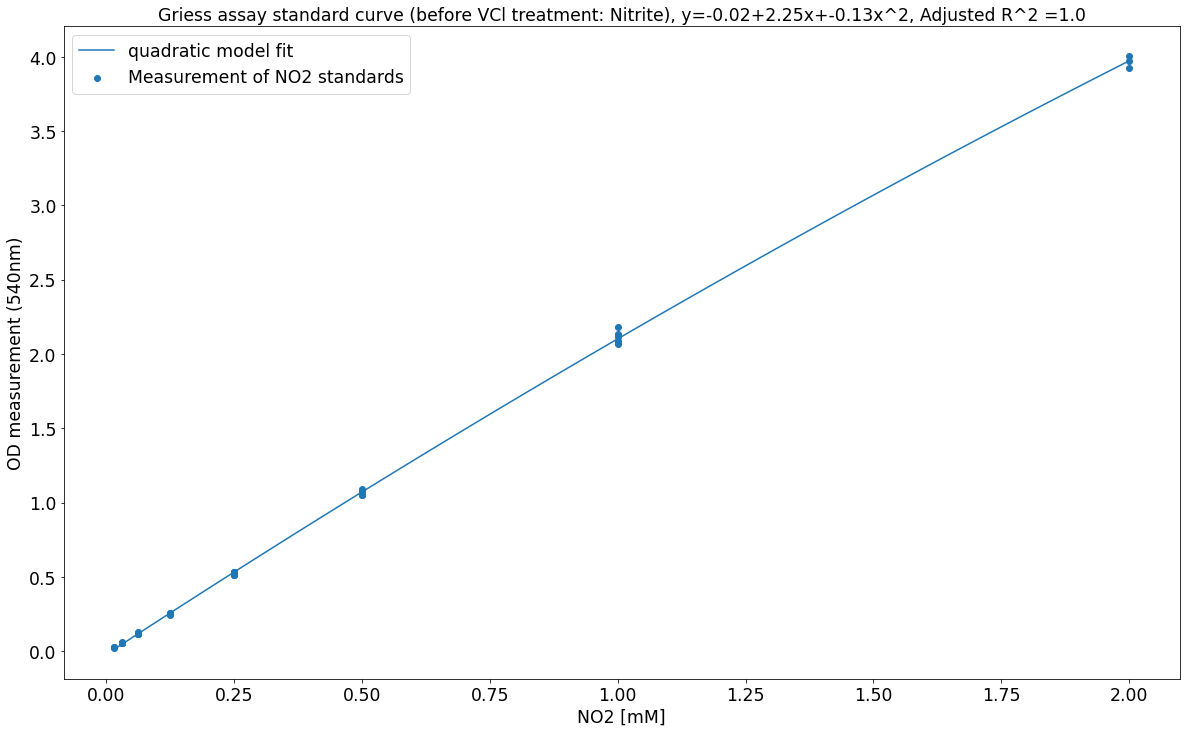

In [3]:
#fit griess assay model using standard curves
std_meta_fn = "./240907_Griess/standards_metadata.csv"
print(std_meta_fn)
std_no2_fn = None
print(std_no2_fn)
std_no2_540_fn = glob.glob("./240907_Griess/*standard*NO2_SCAN*540*")[0]
print(std_no2_540_fn)
std_no2_900_fn = glob.glob("./240907_Griess/*standard*NO2_SCAN*900*")[0]
print(std_no2_900_fn)

std_no2no3_fn = None
std_no2no3_540_fn = glob.glob("./240907_Griess/*standard*NO2NO3_scan*540*")[0]
print(std_no2no3_540_fn)
std_no2no3_900_fn = glob.glob("./240907_Griess/*standard*NO2NO3_scan*900*")[0]
print(std_no2no3_900_fn)

# plot standard curve
gr.plot_griess_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('./240907_Griess/Output/240907_standard_kcl_standard_curve_with_bubble_removal.png')

# fitted parameters
fit_list = gr.fit_griess(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
[[no2_blank,no2no3_blank], g_fit, v_fit, no3_fit] = fit_list


Load standard curve

### (2) After VCl treatment (nitrate reduction to nitrite)

[0.005521820665672639, 1.2064495170000833, -0.06809933118840548]
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0055           0.0040    1.3954    0.1667
1        1.2064           0.0139   87.0714    0.0000
2       -0.0681           0.0067  -10.0940    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          8.090e+04
Date:                Wed, 11 Sep 2024   

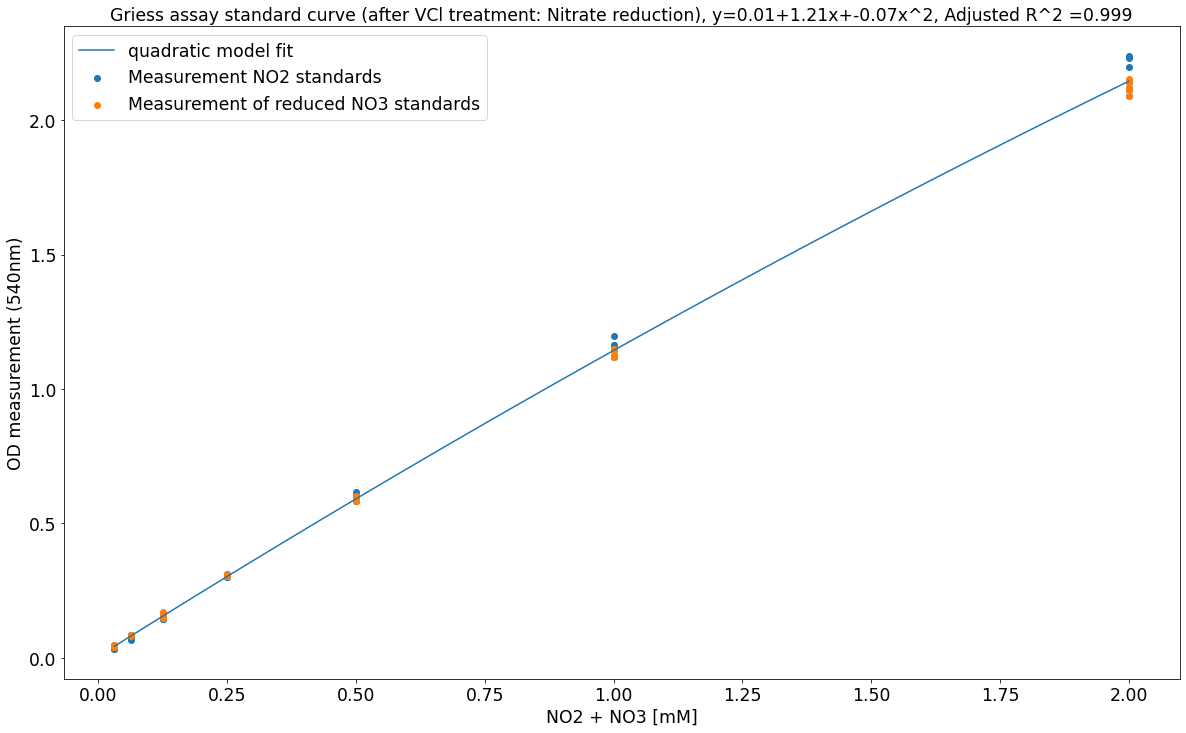

In [4]:
plt.cla()
print(v_fit)

gr.plot_vcl_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('./240907_Griess/Output/240907_standard_kcl_vcl_treated_standard_curve.png')

### (3) Checking the known concentration and the predicted concentration of the NO2-, NO3- mixed standards

returns true for elements more than 1 interquartile ranges above the upper quartile
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []


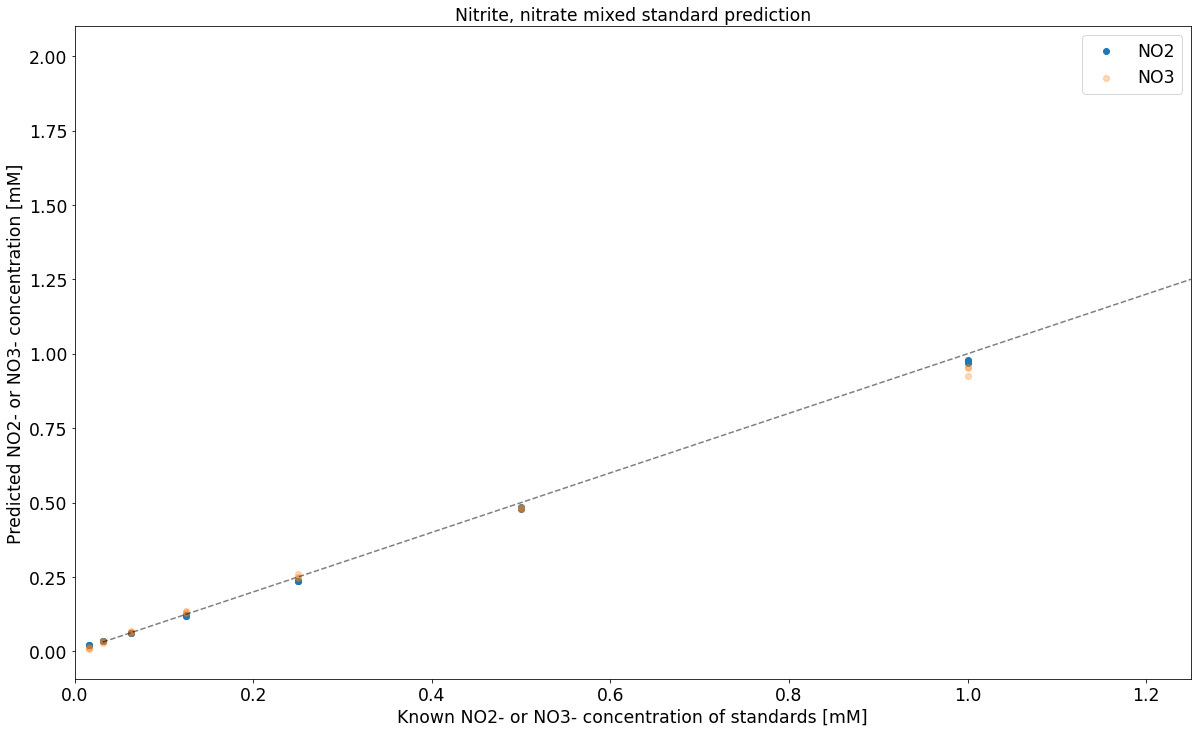

In [5]:
# check mixed conditions prediction
importlib.reload(dn)
gr.plot_mixed_standard_predict(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('./240907_Griess/Output/240907_standard_kcl_mixed_prediction.png')

### (4) Only use nitrate standards for fitting the curve

[0.010587820831263417, 1.2038588832308996, -0.06802534355774988]
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0106           0.0023    4.6845    0.0002
1        1.2039           0.0079  152.1242    0.0000
2       -0.0680           0.0039  -17.6542    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.196e+05
Date:                Wed, 11 Sep 2024   

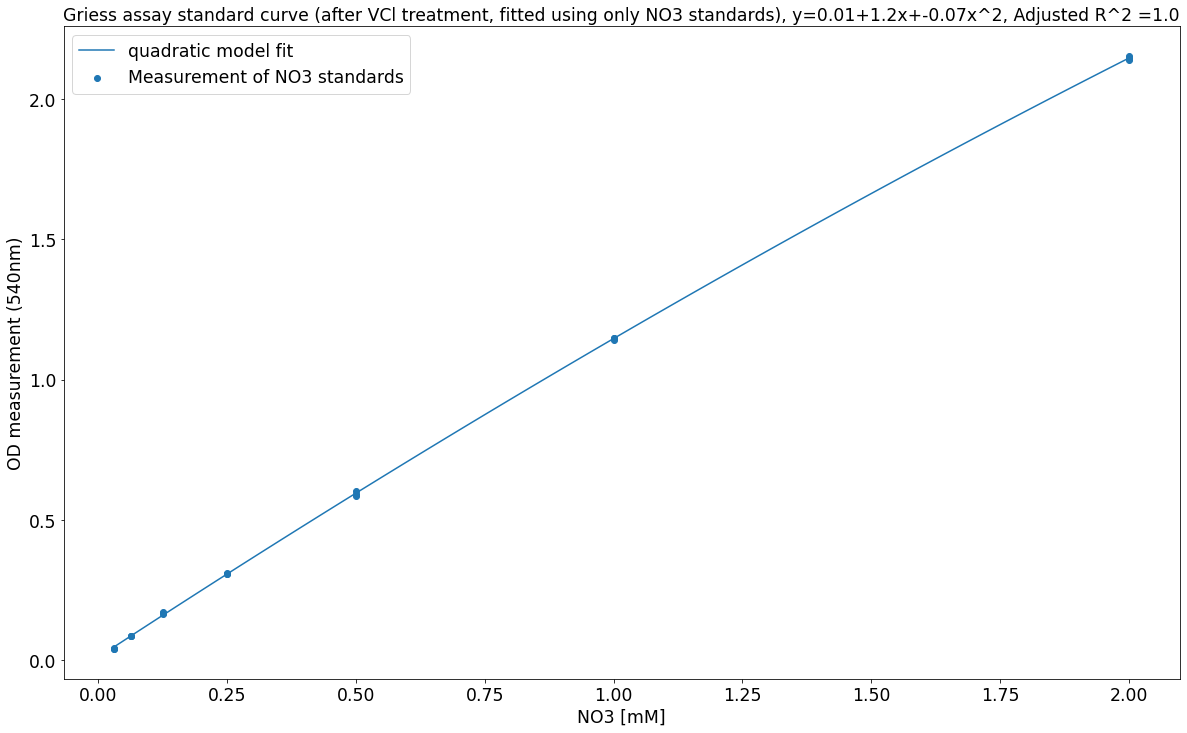

In [6]:
print(no3_fit)

gr.plot_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('./240907_Griess/Output/240907_standard_kcl_vcl_treated_standard_curve_only_using_NO3_standards.png')

returns true for elements more than 1 interquartile ranges above the upper quartile
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []


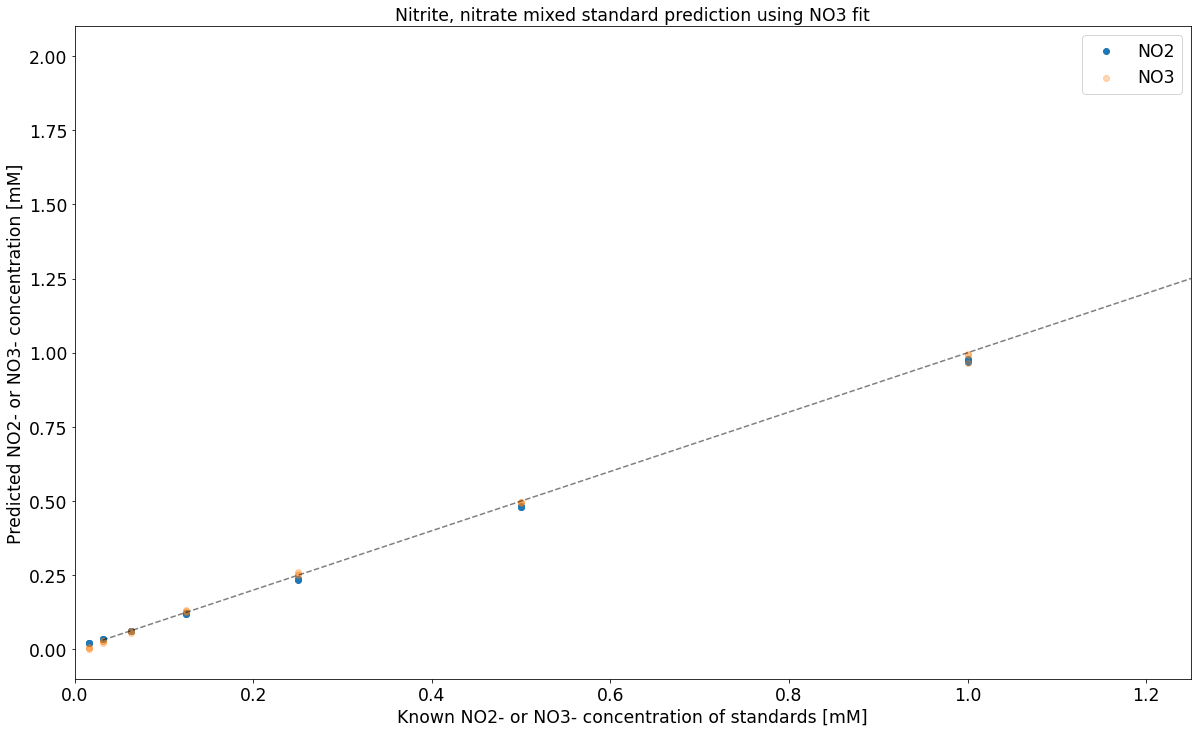

In [7]:
gr.plot_mixed_standard_predict_with_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('./240907_Griess/Output/240907_standard_kcl_mixed_prediction_using_no3_fit.png')

## Make sure that the wellscan is removing all outliers from our data.

In [8]:
## generate all sample names
#l_soil = ["AW_plate1_2", "Starke3","Oxbow3","Washington2"]
l_soil = ["RBW12","RBW34"]
l_timepoint = ['T' + str(i) for i in range(0,10) ]

RBW12_T0
./240907_Griess/sample_metadata_RBW12_T0.csv
None
./240907_Griess\RBW12_T0_20240907_Absorbance_KL_NO2_SCAN_540.csv
./240907_Griess\RBW12_T0_20240907_Absorbance_KL_NO2_SCAN_900.csv
None
./240907_Griess\RBW12_T0_20240908_Absorbance_KL_NO2NO3_SCAN_540.csv
./240907_Griess\RBW12_T0_20240908_Absorbance_KL_NO2NO3_SCAN_900.csv
Check wellscan for outlier removal in NO2
returns true for elements more than 1 interquartile ranges above the upper quartile


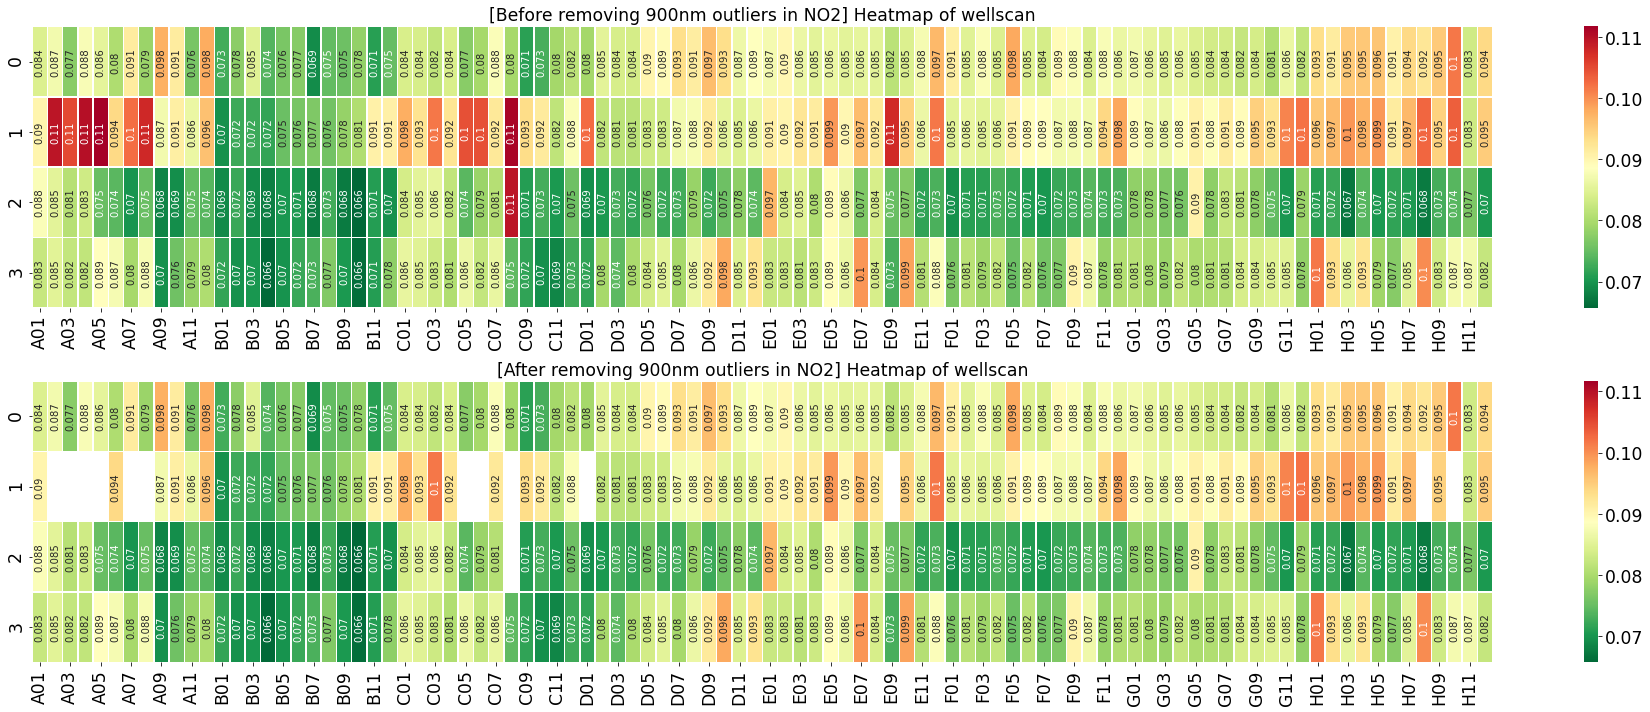

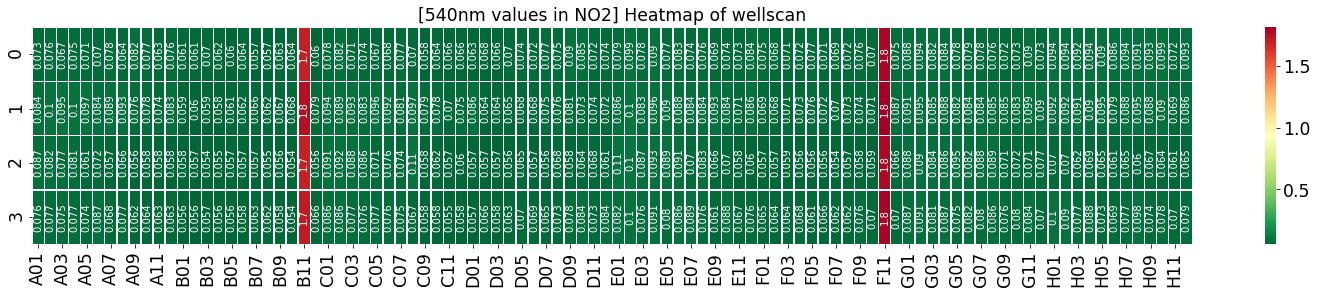

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


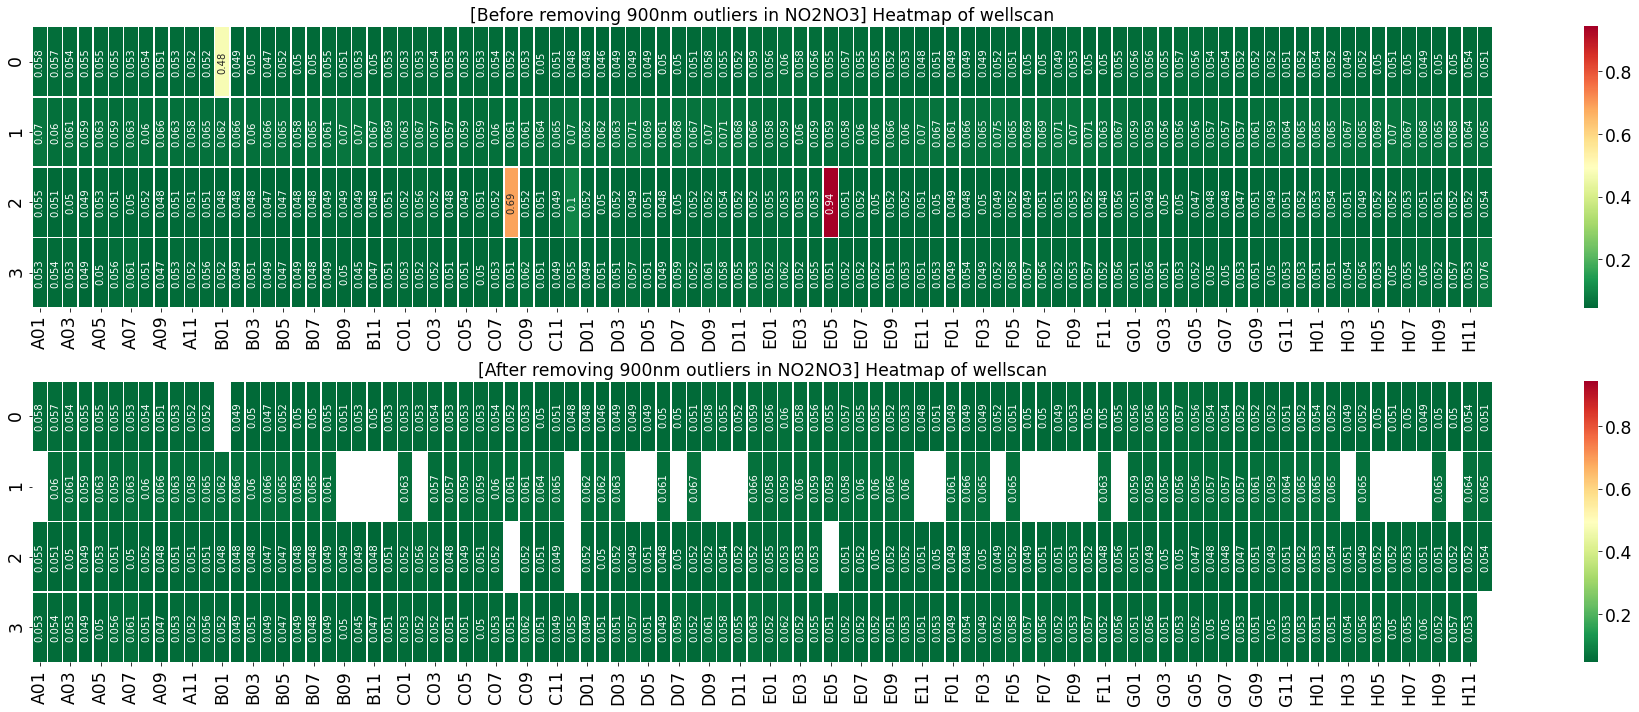

In [ ]:
# Loop through sample names
for i in l_soil:
    for j in l_timepoint:
        sample_name = i+"_"+j
        print(sample_name)
        AW_plate1_2_T0_meta_fn = "./240907_Griess/sample_metadata_"+sample_name+".csv"
        print(AW_plate1_2_T0_meta_fn)
        AW_plate1_2_T0_no2_fn = None
        print(AW_plate1_2_T0_no2_fn)
        AW_plate1_2_T0_no2_540_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2_SCAN_540*")[0]
        print(AW_plate1_2_T0_no2_540_fn)
        AW_plate1_2_T0_no2_900_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2_SCAN_900*")[0]
        print(AW_plate1_2_T0_no2_900_fn)
        AW_plate1_2_T0_no2no3_fn = None
        print(AW_plate1_2_T0_no2no3_fn)
        AW_plate1_2_T0_no2no3_540_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2NO3_SCAN_540*")[0]
        print(AW_plate1_2_T0_no2no3_540_fn)
        AW_plate1_2_T0_no2no3_900_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2NO3_SCAN_900*")[0]
        print(AW_plate1_2_T0_no2no3_900_fn)

        gr.get_concentration_xlsx(excel_output = "./240907_Griess/Output/240907_Griess_"+sample_name+".xlsx",
                                  no2_blank = no2_blank, no2no3_blank = no2no3_blank, g_fit = g_fit, v_fit = no3_fit, 
                             meta_fn = AW_plate1_2_T0_meta_fn, no2_fn=None, no2_540_fn = AW_plate1_2_T0_no2_540_fn, no2_900_fn = AW_plate1_2_T0_no2_900_fn, no2no3_fn=None, no2no3_540_fn=AW_plate1_2_T0_no2no3_540_fn, no2no3_900_fn=AW_plate1_2_T0_no2no3_900_fn)
        
        print("--------------------------------------------------------------------------------------------------------------")

        